# Phase 2.1: Explainable AI (XAI) ile Model Yorumlama
Bu notebook, IP102 veri setinde eğittiğimiz **ViT-B/16** ve **EfficientNet-B4** modellerinin kararlarını nasıl aldıklarını görselleştirmek için hazırlanmıştır (Capstone Task 2.2).

## İçerik:
- Modellerin yüklenmesi
- **Grad-CAM** (Gradient-weighted Class Activation Mapping) ile ısı haritaları oluşturulması
- **SHAP** (SHapley Additive exPlanations) ile özellik önem derecelerinin görselleştirilmesi
- Modellerin karar mekanizmalarının yan yana kıyaslanması

In [9]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import timm

# XAI Kütüphaneleri
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import shap

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {DEVICE}")

Kullanılan Cihaz: cuda


## 1. Eğitilmiş Modellerin Yüklenmesi

In [10]:
num_classes = 102

# 1. ViT Modelini Yükle
vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
vit_model.load_state_dict(torch.load('best_vit_model.pth', map_location=DEVICE, weights_only=True))
vit_model = vit_model.to(DEVICE)
vit_model.eval()

# 2. EfficientNet Modelini Yükle
eff_model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=num_classes)
eff_model.load_state_dict(torch.load('best_efficientnet_model.pth', map_location=DEVICE, weights_only=True))
eff_model = eff_model.to(DEVICE)
eff_model.eval()

print("Her iki model de (ViT ve EfficientNet) başarıyla yüklendi.")

Her iki model de (ViT ve EfficientNet) başarıyla yüklendi.


## 2. Test İçin Örnek Bir Resim Seçimi ve Ön İşleme

In [11]:
def load_and_preprocess_image(img_path):
    # Orijinal resmi BGR'den RGB'ye çevir
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    
    # Görselleştirme için (0-1 arası)
    rgb_img_float = np.float32(img_resized) / 255
    
    # Modele vermek için tensor'a çevir (ImageNet normalization)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(img_resized).unsqueeze(0).to(DEVICE)
    
    return rgb_img_float, input_tensor

# Rastgele bir test/val resmi seçelim
import glob
sample_images = glob.glob('../data/classification/val/*/*.jpg')
if len(sample_images) > 0:
    TEST_IMG_PATH = sample_images[0]
    print(f"Seçilen Resim: {TEST_IMG_PATH}")
    rgb_img, input_tensor = load_and_preprocess_image(TEST_IMG_PATH)
else:
    print("Lütfen geçerli bir resim yolu girin!")

Seçilen Resim: ../data/classification/val\0\00009.jpg


## 3. Grad-CAM Uygulaması
Modellerin tahmini yaparken resmin neresine odaklandığını gösteren ısı haritalarını (heatmap) oluşturuyoruz.

In [12]:
def generate_gradcam(model, input_tensor, rgb_img, target_layers, reshape_transform=None):
    # GradCAM objesini oluştur
    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
    
    # En yüksek olasılıklı sınıf (Tahmin edilen sınıf) için haritayı üret
    targets = None
    
    # Heatmap'i al
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Orijinal resim ile ısı haritasını birleştir
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return visualization

def show_comparisons(rgb_img, vit_cam, eff_cam):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb_img)
    axes[0].set_title('Orijinal Resim')
    axes[0].axis('off')
    
    axes[1].imshow(vit_cam)
    axes[1].set_title('ViT-B/16 Grad-CAM')
    axes[1].axis('off')
    
    axes[2].imshow(eff_cam)
    axes[2].set_title('EfficientNet-B4 Grad-CAM')
    axes[2].axis('off')
    plt.show()

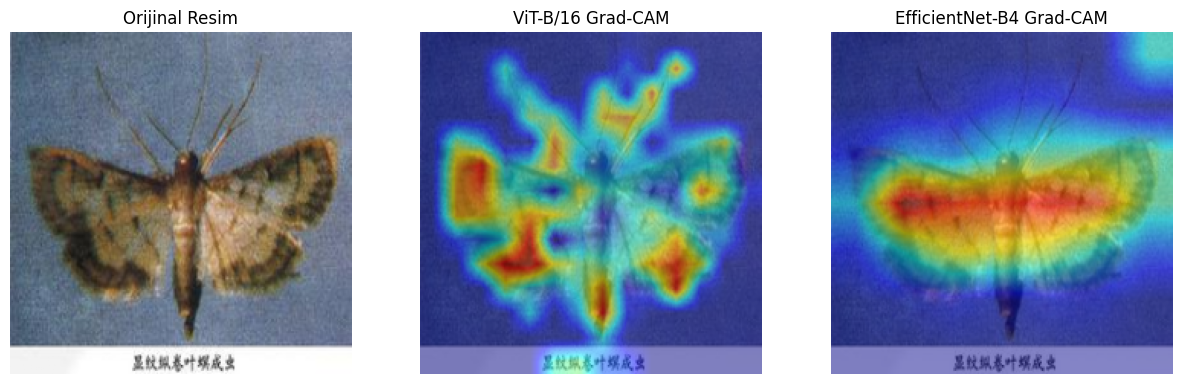

In [13]:
def reshape_transform(tensor, height=14, width=14):
    # ViT için 1D diziyi 2D resme dönüştür (196 patch -> 14x14)
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# ViT için hedef katman (Son bloğun layer norm'u)
vit_target_layers = [vit_model.blocks[-1].norm1]

# EfficientNet için hedef katman (Son konvolüsyon katmanı)
eff_target_layers = [eff_model.conv_head]

# Haritaları üret (ViT modelinde 3D tensor hatasını önlemek için reshape kullanılır)
vit_visualization = generate_gradcam(vit_model, input_tensor, rgb_img, vit_target_layers, reshape_transform=reshape_transform)
eff_visualization = generate_gradcam(eff_model, input_tensor, rgb_img, eff_target_layers)

# Göster
show_comparisons(rgb_img, vit_visualization, eff_visualization)

## 4. SHAP Uygulaması (Gelecekteki Geliştirmeler İçin)
SHAP, her pikselin modelin kararına olan 'katkı payını' matematiksel olarak hesaplar. Bu işlem çok uzun sürebilir, bu yüzden şimdilik basit bir GradientExplainer (veya DeepExplainer) kuruyoruz.

In [16]:
import shap
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Arka plan verisi oluştur (hesaplama için referans)
background = input_tensor 

# EfficientNet için GradientExplainer kullanıyoruz
explainer = shap.GradientExplainer(eff_model, background)

# SHAP değerlerini hesapla
shap_values = explainer.shap_values(input_tensor)

# Çizim için tensörleri NumPy dizisine çevir ve eksenleri ayarla (C, H, W -> H, W, C)
if isinstance(shap_values, list):
    shap_numpy = [np.transpose(s, (0, 2, 3, 1)) for s in shap_values]
else:
    shap_numpy = np.transpose(shap_values, (0, 2, 3, 1))

test_numpy = np.transpose(input_tensor.cpu().numpy(), (0, 2, 3, 1))

# Çizdir
print("EfficientNet-B4 SHAP Değerleri Hesaplanıyor...")
shap.image_plot(shap_numpy, -test_numpy)


KeyboardInterrupt: 